In [37]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from pathlib import Path
import datetime
import linecache
from tqdm import tqdm
from dataclasses import dataclass
from tokenize import String
import re

In [ ]:
MONTH_MAP = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

@dataclass
class waveform:
    file_name : str
    trigTime: datetime.datetime
    channel: int
    min: float = 0
    muon: bool = False

def file_parser(file, threshold):
    file_name = file.stem
    str_time = ""
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(4):
            str_time = f.readline()
    strTime = str_time.split(',')[1]
    channel = int(str(str(file).split('/')[-1]).split('--')[0][-1])
    year   = int(strTime.split(' ')[0].split('-')[-1])
    month  = int(MONTH_MAP[strTime.split(' ')[0].split('-')[-2]])
    day    = int(strTime.split(' ')[0].split('-')[0])
    hour   = int(strTime.split(' ')[1].split(':')[0])
    minute = int(strTime.split(' ')[1].split(':')[1])
    second = int(strTime.split(' ')[1].split(':')[2])
    trigTime = datetime.datetime(year, month, day, hour, minute, second)
    voltages = np.loadtxt(file, skiprows=5, usecols=1, delimiter=',', dtype=float)
    min_voltage = np.min(voltages)
    muon = True if min_voltage <= threshold else False
    return(waveform(file_name, trigTime, channel, min_voltage, muon))

def directory_parser(data_dir, output_csv, threshold):
    files = [f for f in Path(data_dir).iterdir() if f.is_file()]
    files = sorted([f for f in Path(data_dir).iterdir() if f.is_file()])

    with open(output_csv, "a") as myfile:
        myfile.write(f"filename,trigtime,channel,max_amp,muon\n")

    for idx in tqdm(range(len(files))):
        parsed_results = file_parser(files[idx], threshold)
        with open(output_csv, "a") as myfile:
            myfile.write(f"{parsed_results.file_name},{parsed_results.trigTime},{parsed_results.channel},{parsed_results.min},{parsed_results.muon}\n")


In [3]:
data_dir = '/archive/24augrtmuon/24augrtmuon/'
output_csv = "parsed_aug24_rt.csv"

directory_parser(data_dir, output_csv, threshold = -0.006)

100%|██████████| 19052/19052 [01:55<00:00, 165.54it/s]


In [24]:
def find_coincidence(csv_path: str, threshold: float) -> int:
    df = pd.read_csv(csv_path)
    df["_index"] = df["filename"].str.extract(r"--(\d+)$")[0]
    df["trigtime"] = pd.to_datetime(df["trigtime"])
 
    c1 = df[df["filename"].str.startswith("C1")].set_index("_index")
    c2 = df[df["filename"].str.startswith("C2")].set_index("_index")
 
    coincidence_count = 0
    coin_files =[]
    for idx in c1.index.intersection(c2.index):
        if c1.loc[idx, "max_amp"] < threshold and c2.loc[idx, "max_amp"] < threshold:
            coincidence_count += 1
            coin_files.append({
                "file_c1":  c1.loc[idx, "filename"],
                "file_c2":  c2.loc[idx, "filename"],
            })

    first_timestamp = df["trigtime"].min()
    last_timestamp  = df["trigtime"].max()
    duration_s      = ((last_timestamp - first_timestamp).total_seconds())/3600
 
    rate = coincidence_count / duration_s if duration_s > 0 else 0
 
    print(f"First timestamp   : {first_timestamp}")
    print(f"Last timestamp    : {last_timestamp}")
    print(f"Duration          : {duration_s:.2f} hours")
    print(f"Coincidence count : {coincidence_count}")
    print(f"Rate              : {rate:.2f} muons/hour")

    return rate, coin_files

In [29]:
def scan_thresholds(csv_path: str, t_min: float = -0.0006, t_max: float = -0.0004, steps: int = 20):
    thresholds = np.linspace(t_min, t_max, steps)
    rates = []
 
    print(f"{'Threshold':>12} {'Rate (muons/hr)':>18}")
    print("-" * 32)
 
    for t in thresholds:
        rate, _ = find_coincidence(csv_path, threshold=t)
        rates.append(rate)
        print(f"{t:>12.4f} {rate:>18.4f}")
    
    plt.figure(figsize=(14, 8))
    plt.plot(thresholds, rates)
    plt.xlabel("Thresholds (V)")
    plt.ylabel("Coincidence Rate (muons/hour)")
    
    plt.show()

   Threshold    Rate (muons/hr)
--------------------------------
First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 181
Rate              : 10.13 muons/hour
     -0.0006            10.1337
First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 181
Rate              : 10.13 muons/hour
     -0.0006            10.1337
First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 181
Rate              : 10.13 muons/hour
     -0.0006            10.1337
First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 182
Rate              : 10.19 muons/hour
     -0.0006            10.1897
First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coi

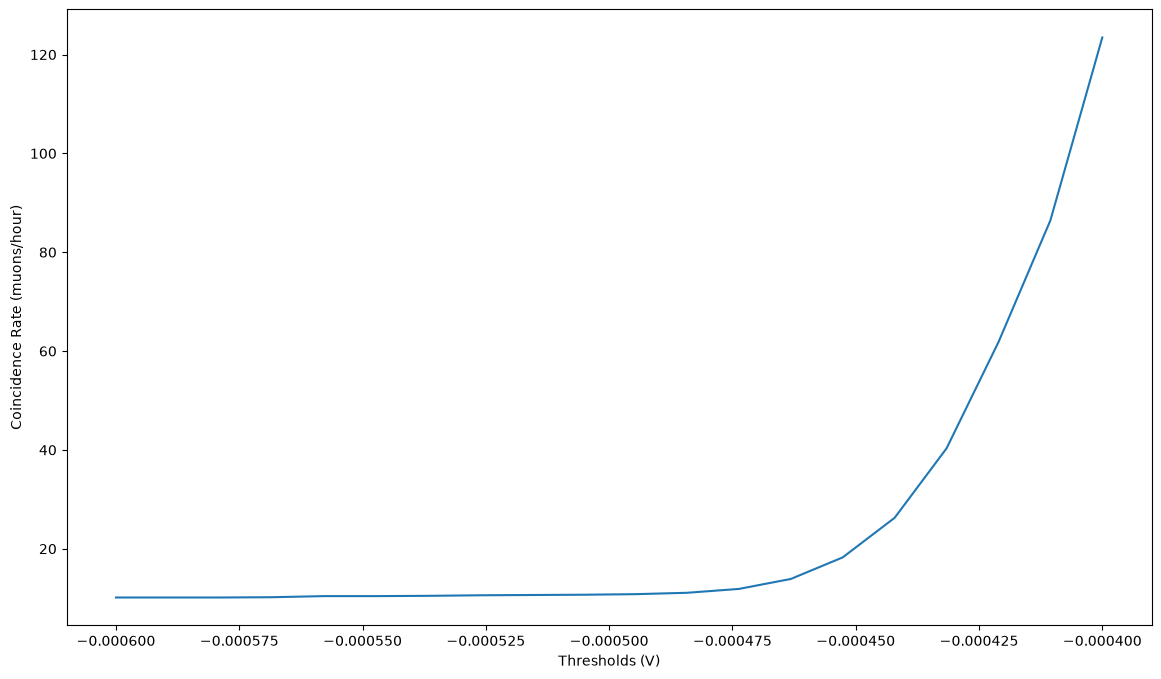

In [30]:
csv_path = "parsed_aug24_rt.csv"

scan_thresholds(csv_path)

In [31]:
rate1, coin_files = find_coincidence(csv_path, threshold=-0.00045)

First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 352
Rate              : 19.71 muons/hour


In [39]:
def plot_waveforms_lecroy(file1, file2, save_dir=None, show=True):
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))

    time = np.loadtxt(file1, skiprows=5, usecols=0, delimiter=',', dtype=float)
    ch1_voltages = np.loadtxt(file1, skiprows=5, usecols=1, delimiter=',', dtype=float)
    ch2_voltages = np.loadtxt(file2, skiprows=5, usecols=1, delimiter=',', dtype=float)

    ax[0].plot(time, ch1_voltages, label='ch1', color='yellow')
    ax[1].plot(time, ch2_voltages, label='ch2', color='violet')

    ax[2].plot(time, ch1_voltages, label="ch1", color="yellow")
    ax[2].plot(time, ch2_voltages, label="ch2", color="violet")

    for axis in ax:
        axis.set_facecolor("black")
        axis.grid()
        axis.legend()
        axis.set_ylabel("Voltage (V)")

    ax[2].set_xlabel("Time (s)")

    fig.tight_layout()
    
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        index = re.search(r"--(\d+)", Path(file1).stem).group(1)
        out_path = save_dir / f"coincidence--{index}.png"
        fig.savefig(out_path, dpi=150)

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_directory_lecroy(data_dir, coin_files, save_dir=None, show=False):
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise NotADirectoryError(f"Directory not found: {data_dir}")

    # Extract indices from the filenames stored in coin_files
    coin_indices = {re.search(r"--(\d+)", entry["file_c1"]).group(1) for entry in coin_files}

    c1_files = {}
    c2_files = {}

    for path in data_dir.iterdir():
        if not path.is_file():
            continue
        name = path.name
        if name.startswith("C1"):
            suffix = name[2:]
            c1_files[suffix] = path
        elif name.startswith("C2"):
            suffix = name[2:]
            c2_files[suffix] = path

    paired_keys = sorted(set(c1_files) & set(c2_files))
    paired_keys = [k for k in paired_keys if any(idx in k for idx in coin_indices)]

    print(f"Plotting {len(paired_keys)} coincidence pairs.")

    processed, skipped = 0, []

    for key in paired_keys:
        file1 = c1_files[key]
        file2 = c2_files[key]
        try:
            plot_waveforms_lecroy(file1, file2, save_dir=save_dir, show=show)
            processed += 1
        except Exception as error:
            skipped.append((file1.name, str(error)))
            print(f"Skipping {file1.name}: {error}")

    print(f"Processed: {processed} pairs")
    print(f"Skipped:   {len(skipped)} pairs")

    return processed, skipped

In [40]:
rate, coin_files = find_coincidence("parsed_aug24_rt.csv", threshold=-0.00045)
dir = '/archive/24augrtmuon/24augrtmuon/'
plot_directory_lecroy(dir, coin_files, save_dir="coinplots_aug24", show=False)

First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 352
Rate              : 19.71 muons/hour
Plotting 352 coincidence pairs.
Processed: 352 pairs
Skipped:   0 pairs


(352, [])

In [41]:
rate_5mv, _ = find_coincidence("parsed_aug24_rt.csv", -0.005)

First timestamp   : 2026-08-24 17:36:27
Last timestamp    : 2026-08-25 11:28:07
Duration          : 17.86 hours
Coincidence count : 138
Rate              : 7.73 muons/hour
